# EDA ระยะเวลาในการปล่อยเช่า (Time-to-Lease)

ผู้รับผิดชอบ: ทอฝัน

Notebook นี้สำรวจข้อมูลก่อนสร้างโมเดล Multiple Linear Regression และ Random Forest Regressor โดยเรียงขั้นตอนคล้าย Notebook 04

1. ทำความเข้าใจประกาศและข้อมูลตลาด
2. ตรวจรายการซ้ำและความถูกต้องของเวลา
3. แบ่งข้อมูลตามเวลา แล้วสำรวจเฉพาะ Train
4. ตรวจการกระจายของ Target และความสัมพันธ์กับคุณลักษณะห้อง ราคา และตลาด
5. สรุปแนวทางสร้าง Feature สำหรับขั้นถัดไป

ข้อมูลทั้งหมดเป็นข้อมูลจำลองเพื่อการศึกษา ผลที่พบไม่ใช่ผลประกอบการจริง

## 1. กำหนดคำถามและ Target

**คำถาม:** เมื่อห้องเริ่มลงประกาศ จากข้อมูลที่มีในวันนั้น คาดว่าจะใช้เวลากี่สัปดาห์จึงปล่อยเช่าสำเร็จ?

- หนึ่งแถวแทนหนึ่งเหตุการณ์ลงประกาศ ไม่ใช่หนึ่งห้องตลอดอายุโครงการ
- Target คือ `weeks_on_market` โดยตรวจเทียบกับ `week_leased - week_listed`
- Regression ใช้เฉพาะรายการที่ปล่อยสำเร็จและทราบผลแล้ว ณ วันตัดข้อมูล
- ห้องที่ยังไม่สำเร็จใช้ตรวจภาพรวม แต่ไม่ถือเวลาที่รอมาแล้วเป็นคำตอบสุดท้าย
- ค่า 0 หมายถึงสำเร็จในสัปดาห์เดียวกัน ไม่ได้ยืนยันว่าใช้เวลา 0 วัน

**ข้อจำกัด:** การเลือกเฉพาะรายการสำเร็จอาจทำให้มองระยะเวลาสั้นเกินไป ผลประเมินจึงไม่ครอบคลุมประกาศที่ยังค้างอยู่ทั้งหมด โมเดลนี้ไม่ให้ค่าความน่าจะเป็นในการปล่อยเช่า

## 2. Import เครื่องมือ

ใช้ pandas จัดตาราง และ matplotlib/seaborn ทำกราฟ โค้ดค้นหารากโปรเจกต์เพื่อให้เปิดได้ทั้งจากโฟลเดอร์หลักและ notebooks

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from IPython.display import display

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "src" / "kaverentai").is_dir()
)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from kaverentai.data.load_data import load_all_data
from kaverentai.data.types import coerce_boolean
from kaverentai.features.time_to_lease_features import assign_time_split
from kaverentai.config import (
    TIME_TO_LEASE_MIN_FOLLOW_UP_WEEKS, TIME_TO_LEASE_TEST_END
)

sns.set_theme(style="whitegrid")
thai_font = Path("C:/Windows/Fonts/tahoma.ttf")
if thai_font.exists():
    font_manager.fontManager.addfont(str(thai_font))
    plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(thai_font)).get_name()
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 30)
TARGET = "weeks_on_market"
print("Project:", PROJECT_ROOT)

Project: D:\final project


## 3. โหลดข้อมูลและดูตัวอย่าง

ใช้ listings ซึ่งมีรายละเอียดห้องและราคาตั้งต้นแล้ว และ weekly_market สำหรับข้อมูลตลาดย้อนหลัง ไม่จำเป็นต้องรวม leases เพราะข้อมูลสัญญาเกิดหลังเวลาที่ต้องการทำนาย

In [2]:
tables = load_all_data(cleaned=True)
listings = tables["listings"].copy()
market = tables["weekly_market"].copy()
print("ประกาศ:", len(listings), "แถว")
print("ข้อมูลตลาด:", len(market), "แถว")
display(listings.head())
display(market.head())

ประกาศ: 31544 แถว
ข้อมูลตลาด: 2288 แถว


,listing_id,unit_id,project_id,project_name,university,distance_to_campus_m,facility_count,agent_id,floor,size_sqm,room_type,view,furnished,week_listed,date_listed,season_listed,asking_rent,first_asking_rent,weeks_on_market,n_viewings,leased,week_leased,tenant_segment,lease_months
0,LS030060,U120165,12,Kave Coco Bangsaen,ม.บูรพา,500,50,AG05,1,23.6,studio,standard,True,178,2026-06-02,peak,12040.0,12040.0,0,3,True,178.0,firstjob,12.0
1,LS003809,U020403,2,Kave Town Shift,ม.กรุงเทพ,200,30,AG01,3,26.8,studio,standard,True,30,2023-08-01,peak,11670.0,11670.0,0,7,True,30.0,year1,12.0
2,LS002276,U040987,4,Kave Town Colony,ม.กรุงเทพ,300,40,AG02,2,31.9,1BR,standard,True,11,2023-03-21,off,11050.0,11590.0,5,3,True,16.0,year2_3,6.0
3,LS023906,U140114,14,Kave Mutant Salaya,ม.มหิดล,750,30,AG05,4,25.9,studio,standard,True,153,2025-12-09,off,8290.0,9770.0,14,7,True,167.0,year2_3,12.0
4,LS024271,U070664,7,Kave Wonderland,ม.ธรรมศาสตร์,250,45,AG02,6,22.5,studio,city,True,156,2025-12-30,normal,11770.0,11770.0,1,3,True,157.0,year1,12.0


,week,date,project_id,season,n_searchers,n_listings_open,n_units_leased,occupancy,median_asking_rent
0,0,2023-01-03,0,normal,21,101,488,0.828523,10010.0
1,0,2023-01-03,1,normal,39,166,907,0.845294,10480.0
2,0,2023-01-03,2,normal,36,180,893,0.832246,10965.0
3,0,2023-01-03,3,normal,55,285,1485,0.838983,11110.0
4,0,2023-01-03,4,normal,40,155,928,0.856879,11260.0


## 4. ตรวจชนิดข้อมูล Missing Value และรหัสซ้ำ

ตรวจโครงสร้างทั้งชุดได้ แต่กราฟ Target และการตัดสินใจเลือก Feature จะใช้ Train เท่านั้น ค่า week_leased ที่หายไปในรายการยังไม่สำเร็จเป็นสิ่งที่คาดได้ ไม่ควรเติมเป็นสัปดาห์ที่เช่าสำเร็จ

In [3]:
listings["date_listed"] = pd.to_datetime(listings["date_listed"], errors="raise")
market["date"] = pd.to_datetime(market["date"], errors="raise")
listings["leased"] = coerce_boolean(listings["leased"], "leased")
listings["furnished"] = coerce_boolean(listings["furnished"], "furnished")
for col in ["week_listed", "week_leased", TARGET, "first_asking_rent"]:
    listings[col] = pd.to_numeric(listings[col], errors="raise")

display(listings.dtypes.astype(str).to_frame("ชนิดข้อมูล"))
missing = listings.isna().sum()
display(missing[missing > 0].to_frame("จำนวน Missing"))
print("listing_id ซ้ำ:", listings["listing_id"].duplicated().sum())
assert not listings["listing_id"].duplicated().any(), "ต้องตรวจรหัสประกาศซ้ำก่อน"
assert not market.duplicated(["project_id", "week"]).any(), "ข้อมูลตลาดมี key ซ้ำ"
assert listings["listing_id"].notna().all()
assert listings[TARGET].notna().all()
assert listings[TARGET].ge(0).all()

listing_id ซ้ำ: 0


,ชนิดข้อมูล
listing_id,str
unit_id,str
project_id,int64
project_name,str
university,str
distance_to_campus_m,int64
facility_count,int64
agent_id,str
floor,int64
size_sqm,float64


,จำนวน Missing
week_leased,566
tenant_segment,566
lease_months,566


### 4.1 ตรวจประกาศที่ลงท้าย -B

ชุดข้อมูลนี้มีประกาศทางเลือกที่ต้องตรวจเทียบกับรหัสต้นฉบับก่อนตัดออก หากห้อง วันลงประกาศ และผลลัพธ์ตรงกัน จะใช้เฉพาะแถวต้นฉบับเพื่อไม่ให้นับเหตุการณ์เดียวกันซ้ำ ส่วนห้องเดิมที่กลับมาลงประกาศคนละวันยังเก็บไว้

In [4]:
is_alternative = listings["listing_id"].str.endswith("-B")
alternatives = listings.loc[is_alternative].copy()
base = listings.loc[~is_alternative].copy()
alternatives["base_id"] = alternatives["listing_id"].str[:-2]
check_columns = ["unit_id", "project_id", "date_listed", "leased", TARGET, "week_leased"]
pairs = alternatives.merge(
    base[["listing_id", *check_columns]],
    left_on="base_id", right_on="listing_id", how="left",
    suffixes=("_alt", "_base"), validate="many_to_one", indicator=True
)
assert pairs["_merge"].eq("both").all(), "พบ -B ที่ไม่มีต้นฉบับ"
for col in check_columns:
    a, b = pairs[f"{col}_alt"], pairs[f"{col}_base"]
    assert (a.eq(b) | (a.isna() & b.isna())).all(), f"ต้องตรวจคู่ -B ที่ต่างกัน: {col}"

clean_listings = base.copy()
print("รายการทางเลือกที่ไม่นับซ้ำ:", len(alternatives))
print("ประกาศที่เหลือ:", len(clean_listings))
print("ห้องและวันเดียวกันซ้ำ:", clean_listings.duplicated(["unit_id", "date_listed"]).sum())
display(clean_listings["leased"].value_counts().rename_axis("ปล่อยสำเร็จ").to_frame("จำนวนประกาศ"))

รายการทางเลือกที่ไม่นับซ้ำ: 1066
ประกาศที่เหลือ: 30478
ห้องและวันเดียวกันซ้ำ: 0


,จำนวนประกาศ
ปล่อยสำเร็จ,
True,29928
False,550


### 4.2 ตรวจ Target กับสัปดาห์ที่ปล่อยสำเร็จ

ตรวจสูตรเวลาและสร้างวันที่อ้างอิงจากปฏิทินสัปดาห์ เราไม่ทราบวันเซ็นสัญญาที่แน่นอน จึงใช้สิ้นสุดสัปดาห์เป็นวันที่ทราบผลแบบระมัดระวังในการแบ่งชุดข้อมูล

In [5]:
calendar = market[["week", "date"]].drop_duplicates()
assert not calendar["week"].duplicated().any()
week_dates = calendar.set_index("week")["date"]
assert week_dates.sort_index().diff().dropna().eq(pd.Timedelta(days=7)).all()
assert clean_listings["date_listed"].eq(clean_listings["week_listed"].map(week_dates)).all()

success = clean_listings["leased"]
duration_check = (
    clean_listings.loc[success, "week_leased"]
    - clean_listings.loc[success, "week_listed"]
)
assert duration_check.eq(clean_listings.loc[success, TARGET]).all(), "Target ไม่ตรงกับสัปดาห์"
clean_listings["outcome_available_at"] = (
    clean_listings["week_leased"].map(week_dates) + pd.Timedelta(days=7)
)
assert clean_listings.loc[success, "outcome_available_at"].notna().all()
observation_end = market["date"].max() + pd.Timedelta(days=7)
print("ตรวจสูตร Target ผ่าน")
print("จุดสิ้นสุดการติดตามที่ใช้:", observation_end.date())

ตรวจสูตร Target ผ่าน
จุดสิ้นสุดการติดตามที่ใช้: 2026-06-30


## 5. เพิ่มข้อมูลตลาดก่อนวันลงประกาศ

ใช้ข้อมูลตลาดของสัปดาห์ก่อนหน้า โดยสมมติว่าสรุปรายสัปดาห์พร้อมใช้งานเมื่อจบสัปดาห์ หากระบบจริงเผยแพร่ช้ากว่านั้นต้องเลื่อนข้อมูลย้อนหลังเพิ่ม

- rent_to_market_ratio = ราคาตั้งต้น ÷ ราคากลางตลาดสัปดาห์ก่อน
- market_demand_pressure = ผู้ค้นหา ÷ จำนวนประกาศเปิดสัปดาห์ก่อน

ประกาศในสัปดาห์แรกของข้อมูลแต่ละโครงการอาจไม่มีข้อมูลย้อนหลัง ให้คง Missing ไว้และแจ้งจำนวน ไม่เติมด้วยข้อมูลอนาคต

ผลตรวจข้อมูลชุดปัจจุบัน: ประกาศที่ไม่มีตลาดย้อนหลัง 7,964 รายการอยู่ในสัปดาห์ 0, 52, 104 และ 156 ซึ่งตรงกับสัปดาห์แรกที่มีข้อมูลตลาดของโครงการนั้น จึงไม่ได้เกิดจากการรวมตารางผิด แต่ต้องจัดการ Missing ในขั้นสร้าง Pipeline และตรวจผลแยกกลุ่มนี้

In [6]:
lag_market = market[[
    "project_id", "week", "date", "occupancy",
    "n_searchers", "n_listings_open", "median_asking_rent"
]].copy()
lag_market["week_listed"] = lag_market["week"] + 1
lag_market["market_available_at"] = lag_market["date"] + pd.Timedelta(days=7)
lag_market = lag_market.rename(columns={
    "occupancy": "market_occupancy",
    "n_searchers": "market_n_searchers",
    "n_listings_open": "market_n_listings_open",
    "median_asking_rent": "market_median_asking_rent"
})
analysis_data = clean_listings.merge(
    lag_market.drop(columns=["week", "date"]),
    on=["project_id", "week_listed"], how="left", validate="many_to_one"
)
known_market = analysis_data["market_available_at"].notna()
assert (analysis_data.loc[known_market, "market_available_at"]
        <= analysis_data.loc[known_market, "date_listed"]).all()
assert len(analysis_data) == len(clean_listings)
analysis_data["rent_to_market_ratio"] = (
    analysis_data["first_asking_rent"]
    / analysis_data["market_median_asking_rent"].where(
        analysis_data["market_median_asking_rent"] > 0)
)
analysis_data["market_demand_pressure"] = (
    analysis_data["market_n_searchers"]
    / analysis_data["market_n_listings_open"].where(
        analysis_data["market_n_listings_open"] > 0)
)
analysis_data["listing_month"] = analysis_data["date_listed"].dt.month
analysis_data["listing_year"] = analysis_data["date_listed"].dt.year
analysis_data["missing_market_history"] = ~known_market
print("ไม่มีข้อมูลตลาดสัปดาห์ก่อน:", (~known_market).sum(), "รายการ")
display(analysis_data[[
    "listing_id", "date_listed", "market_available_at",
    "first_asking_rent", "market_median_asking_rent", "rent_to_market_ratio"
]].head())

ไม่มีข้อมูลตลาดสัปดาห์ก่อน: 7964 รายการ


,listing_id,date_listed,market_available_at,first_asking_rent,market_median_asking_rent,rent_to_market_ratio
0,LS030060,2026-06-02,2026-06-02,12040.0,12370.0,0.973323
1,LS003809,2023-08-01,2023-08-01,11670.0,11245.0,1.037795
2,LS002276,2023-03-21,2023-03-21,11590.0,11180.0,1.036673
3,LS023906,2025-12-09,2025-12-09,9770.0,10940.0,0.893053
4,LS024271,2025-12-30,2025-12-30,11770.0,11430.0,1.029746


## 6. แบ่ง Train / Validation / Test ก่อนสำรวจความสัมพันธ์

ใช้ **Matured Time Split** โดยถอย Test มาเป็นเมษายน-มิถุนายน 2025 เพื่อให้มีเวลาติดตามอย่างน้อย 52 สัปดาห์ก่อนข้อมูลสิ้นสุด ส่วนรายการหลังจากนั้นเป็น `post_test` และไม่ใช้เลือกหรือวัดผลโมเดล

ตารางแสดงจำนวนประกาศสำเร็จและยังไม่สำเร็จในแต่ละช่วง ส่วนกราฟหลังจากนี้ใช้ **Train ที่ปล่อยเช่าสำเร็จแล้ว** เท่านั้น ไม่มีการเปิด Target ของ Validation หรือ Test เพื่อเลือก Feature

In [7]:
analysis_data["data_split"] = assign_time_split(analysis_data["date_listed"])
follow_up_weeks = (
    observation_end - pd.Timestamp(TIME_TO_LEASE_TEST_END)
).days // 7
assert follow_up_weeks >= TIME_TO_LEASE_MIN_FOLLOW_UP_WEEKS
split_frames = {}
audit_rows = []
for split_name in ["train", "validation", "test", "post_test"]:
    frame = analysis_data.loc[analysis_data["data_split"] == split_name].copy()
    successful = frame["leased"]
    split_frames[split_name] = frame.loc[successful].copy()
    audit_rows.append({
        "ชุดข้อมูล": split_name, "ประกาศทั้งหมด": len(frame),
        "ปล่อยเช่าสำเร็จ": int(successful.sum()),
        "ยังไม่สำเร็จ": int((~successful).sum()),
        "อัตราสำเร็จ (%)": successful.mean() * 100 if len(frame) else np.nan,
        "วันลงประกาศแรก": frame["date_listed"].min(),
        "วันลงประกาศสุดท้าย": frame["date_listed"].max()
    })
split_summary = pd.DataFrame(audit_rows)
display(split_summary)
eda_data = split_frames["train"].copy()
assert len(eda_data) > 0
print("ระยะติดตามขั้นต่ำหลัง Test:", follow_up_weeks, "สัปดาห์")
print("ใช้ EDA:", len(eda_data), "แถวจาก Matured Train")
print("Missing Feature ใน Train:")
display(eda_data[["market_occupancy", "rent_to_market_ratio", "market_demand_pressure"]]
        .isna().sum().to_frame("จำนวน"))

ระยะติดตามขั้นต่ำหลัง Test: 52 สัปดาห์
ใช้ EDA: 16993 แถวจาก Matured Train
Missing Feature ใน Train:


,ชุดข้อมูล,ประกาศทั้งหมด,ปล่อยเช่าสำเร็จ,ยังไม่สำเร็จ,อัตราสำเร็จ (%),วันลงประกาศแรก,วันลงประกาศสุดท้าย
0,train,17015,16993,22,99.870702,2023-01-03,2024-12-31
1,validation,1045,1045,0,100.000000,2025-01-07,2025-03-25
2,test,2268,2247,21,99.074074,2025-04-01,2025-06-24
3,post_test,10150,9643,507,95.004926,2025-07-01,2026-06-23


,จำนวน
market_occupancy,6067
rent_to_market_ratio,6067
market_demand_pressure,6067


## 7. สำรวจระยะเวลาปล่อยเช่า

ดูค่าสถิติ Histogram และ Boxplot ควบคู่กัน เส้นมัธยฐานแบ่งข้อมูลเป็นสองฝั่งเท่า ๆ กัน ส่วนจุดนอกหนวด Boxplot เป็นเพียงรายการที่ควรตรวจ ไม่ใช่ข้อผิดพลาดทุกจุด

สำเร็จในสัปดาห์เดียวกัน: 3896 รายการ
Skewness: 2.551


,สัปดาห์
count,16993.000000
mean,8.442359
std,11.022965
min,0.000000
25%,1.000000
50%,3.000000
75%,16.000000
90%,22.000000
95%,26.000000
99%,44.000000


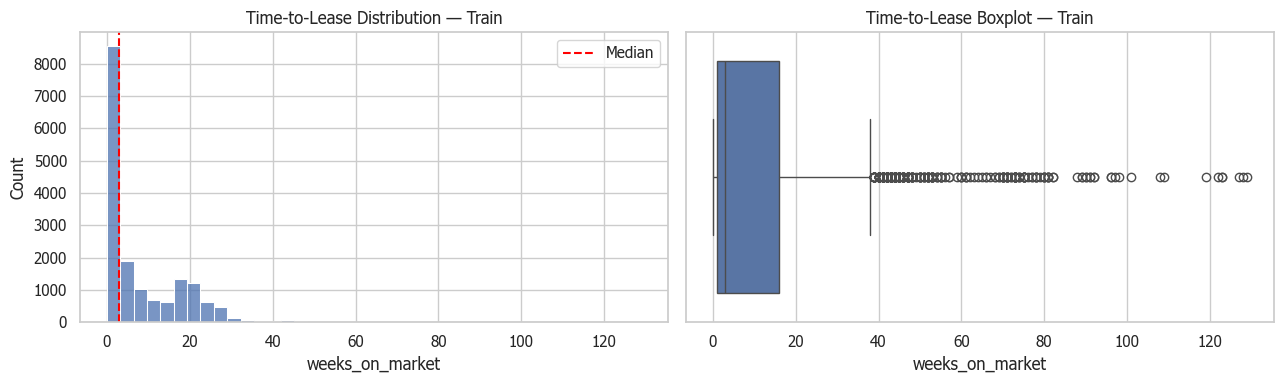

In [8]:
target_stats = eda_data[TARGET].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
display(target_stats.to_frame("สัปดาห์"))
print("สำเร็จในสัปดาห์เดียวกัน:", eda_data[TARGET].eq(0).sum(), "รายการ")
print("Skewness:", round(eda_data[TARGET].skew(), 3))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=eda_data, x=TARGET, bins=40, ax=axes[0])
axes[0].axvline(eda_data[TARGET].median(), color="red", linestyle="--", label="Median")
axes[0].legend()
sns.boxplot(data=eda_data, x=TARGET, ax=axes[1])
axes[0].set_title("Time-to-Lease Distribution — Train")
axes[1].set_title("Time-to-Lease Boxplot — Train")
plt.tight_layout()
plt.show()

### 7.1 ตรวจ Outlier และลองดู log1p

นับรายการเกิน 26, 52 และ 104 สัปดาห์เพื่อเห็นขนาดของหางการกระจาย และตรวจเกณฑ์ IQR จาก Train เท่านั้น ในขั้นนี้ยังเก็บค่าจริงทั้งหมด

log1p คือ log(1 + จำนวนสัปดาห์) จึงรองรับค่า 0 ใช้เพื่อสำรวจการกระจายก่อน การแปลง Target จริงต้องตัดสินจาก Validation และประเมินกลับในหน่วยสัปดาห์

Matured Train ที่สำเร็จภายใน 52 สัปดาห์: 99.34%


,เกณฑ์,จำนวน
0,> 26 สัปดาห์,823
1,> 52 สัปดาห์,112
2,> 104 สัปดาห์,9
3,> 38.5 สัปดาห์,274


,listing_id,project_name,date_listed,first_asking_rent,weeks_on_market
17990,LS008282,Kave Genesis Nakhon Pathom,2024-01-02,11500.0,129
16592,LS008342,Kave Genesis Nakhon Pathom,2024-01-02,14310.0,128
24464,LS007322,Kave Seed Kaset,2024-01-02,11280.0,127
20076,LS007612,Kave Seed Kaset,2024-01-02,10290.0,123
21535,LS007092,Kave Seed Kaset,2024-01-02,8440.0,123
28959,LS007472,Kave Seed Kaset,2024-01-02,10930.0,122
1702,LS007254,Kave Seed Kaset,2024-01-02,12250.0,119
4441,LS008190,Kave Genesis Nakhon Pathom,2024-01-02,14810.0,109
2818,LS008435,Kave Genesis Nakhon Pathom,2024-01-02,10000.0,108
17607,LS007855,Kave Pop Salaya,2024-01-02,13670.0,101


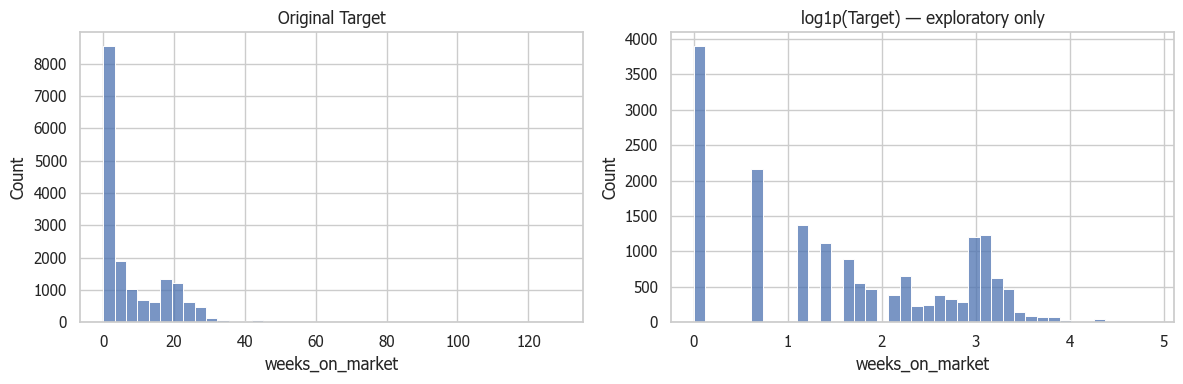

In [9]:
q1, q3 = eda_data[TARGET].quantile([0.25, 0.75])
upper_iqr = q3 + 1.5 * (q3 - q1)
outlier_summary = pd.DataFrame([
    {"เกณฑ์": f"> {limit:g} สัปดาห์", "จำนวน": int(eda_data[TARGET].gt(limit).sum())}
    for limit in [26, 52, 104, upper_iqr]
])
display(outlier_summary)
coverage_52 = eda_data[TARGET].le(52).mean() * 100
print(f"Matured Train ที่สำเร็จภายใน 52 สัปดาห์: {coverage_52:.2f}%")
display(eda_data.nlargest(10, TARGET)[[
    "listing_id", "project_name", "date_listed", "first_asking_rent", TARGET
]])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(eda_data[TARGET], bins=40, ax=axes[0])
sns.histplot(np.log1p(eda_data[TARGET]), bins=40, ax=axes[1])
axes[0].set_title("Original Target")
axes[1].set_title("log1p(Target) — exploratory only")
plt.tight_layout()
plt.show()

## 8. ราคา ขนาด ชั้น และทำเลสัมพันธ์กับเวลาอย่างไร?

แต่ละจุดแทนประกาศหนึ่งรายการ หากจุดซ้อนกันมากให้ดูแนวโน้มร่วมกับ Correlation ในขั้นถัดไป ค่า rent_to_market_ratio มากกว่า 1 หมายถึงตั้งราคาสูงกว่าราคากลางสัปดาห์ก่อน แต่ยังไม่ใช่การเทียบห้องที่มีคุณสมบัติเหมือนกันทุกด้าน

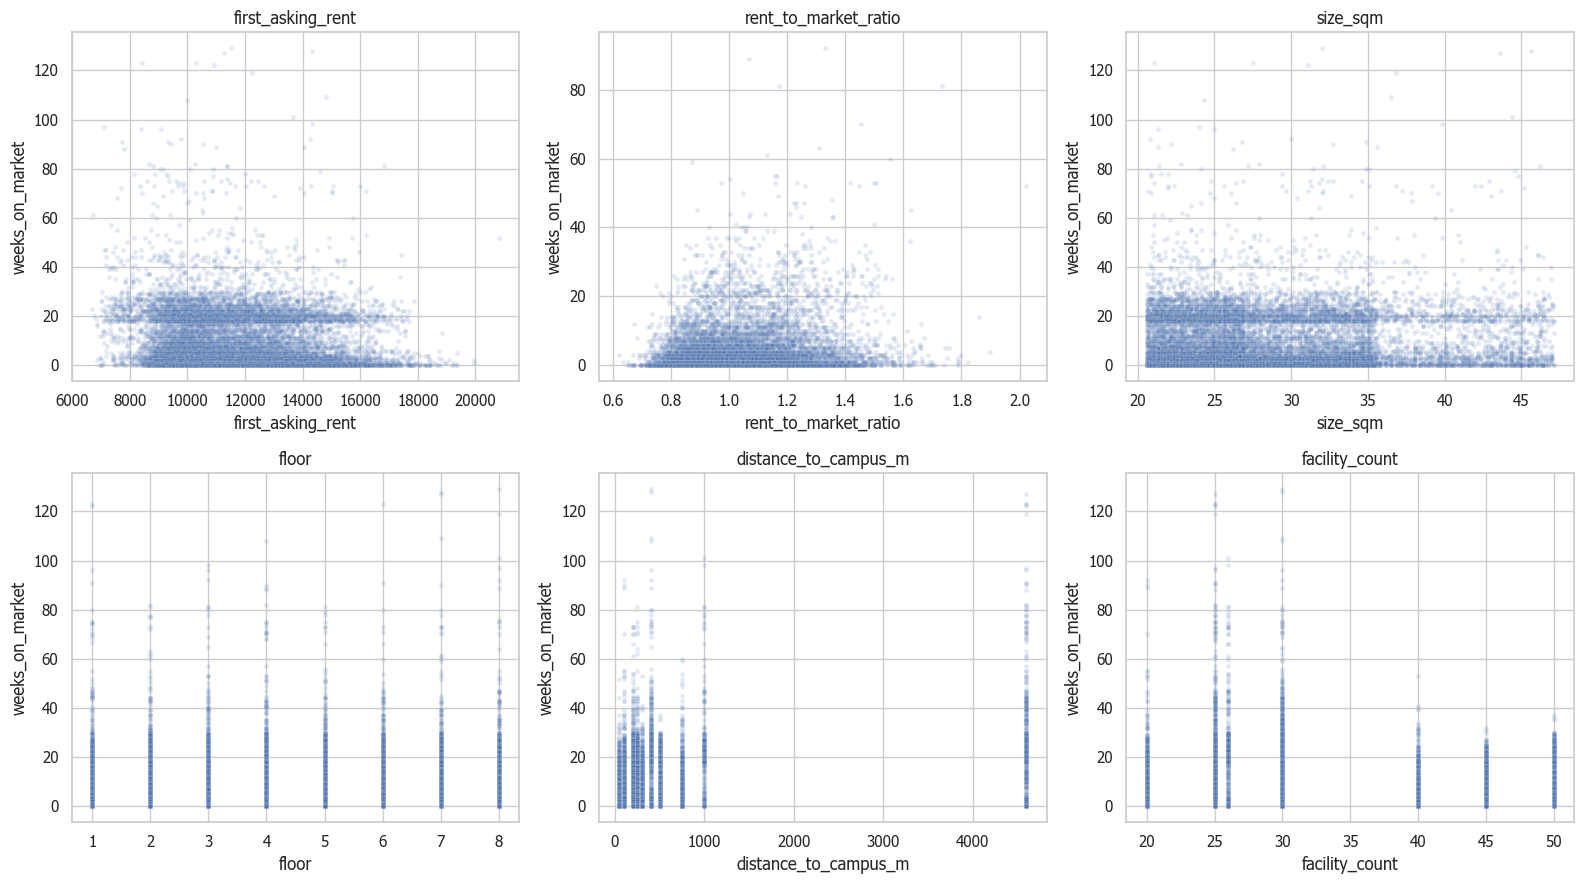

In [10]:
numeric_plot_columns = [
    "first_asking_rent", "rent_to_market_ratio", "size_sqm",
    "floor", "distance_to_campus_m", "facility_count"
]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, numeric_plot_columns):
    sns.scatterplot(data=eda_data, x=col, y=TARGET, alpha=0.15, s=12, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 9. ประเภทห้อง วิว เฟอร์นิเจอร์ และฤดูกาล

แสดงจำนวนรายการและค่ามัธยฐานแต่ละกลุ่มก่อนอ่านกราฟ เพื่อไม่สรุปจากกลุ่มที่มีตัวอย่างน้อย ความแตกต่างอาจสัมพันธ์กับราคาและโครงการร่วมด้วย

แบ่งตาม: room_type
แบ่งตาม: view
แบ่งตาม: furnished
แบ่งตาม: season_listed


,count,median,mean
room_type,,,
1BR,5379,5.0,9.54
1BR Plus,1686,6.0,11.52
studio,9928,3.0,7.32


,count,median,mean
view,,,
city,4097,4.0,8.93
pool,2299,4.0,9.53
standard,10597,3.0,8.02


,count,median,mean
furnished,,,
False,3535,11.0,14.7
True,13458,3.0,6.8


,count,median,mean
season_listed,,,
normal,4454,2.0,3.40
off,2537,7.0,8.42
peak,7399,16.0,12.89
shoulder,2603,1.0,4.43


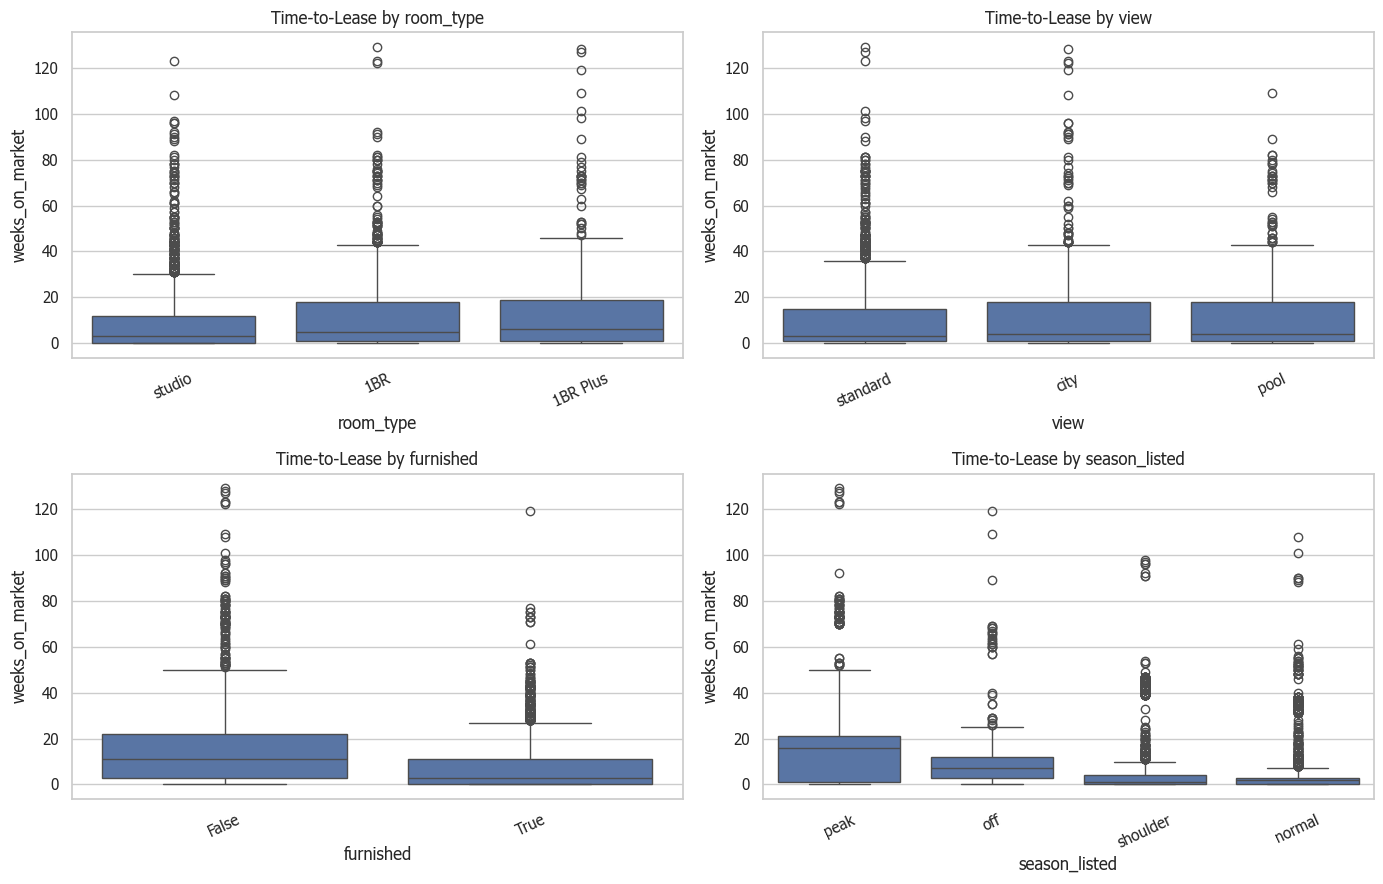

In [11]:
group_columns = ["room_type", "view", "furnished", "season_listed"]
for col in group_columns:
    print("แบ่งตาม:", col)
    display(eda_data.groupby(col, dropna=False)[TARGET].agg(["count", "median", "mean"]).round(2))
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flat, group_columns):
    sns.boxplot(data=eda_data, x=col, y=TARGET, ax=ax)
    ax.set_title(f"Time-to-Lease by {col}")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

### 9.1 เปรียบเทียบแต่ละโครงการ

ใช้ค่ามัธยฐานเพื่อลดอิทธิพลของรายการที่ใช้เวลานานมาก แต่ยังต้องดูจำนวนรายการกำกับ

,count,median,mean
project_name,,,
Kave Ava,1809,1.0,3.03
Kave Town Island,2602,1.0,2.87
Kave TU,1455,2.0,3.93
Kave Town Colony,1521,2.0,4.00
Kave Town Shift,1584,2.0,4.94
Kave Town Space,1519,2.0,4.71
Kave Mutant Salaya,793,4.0,7.70
Kave Condo,799,5.0,9.25
Kave Wonderland,1423,18.0,13.53


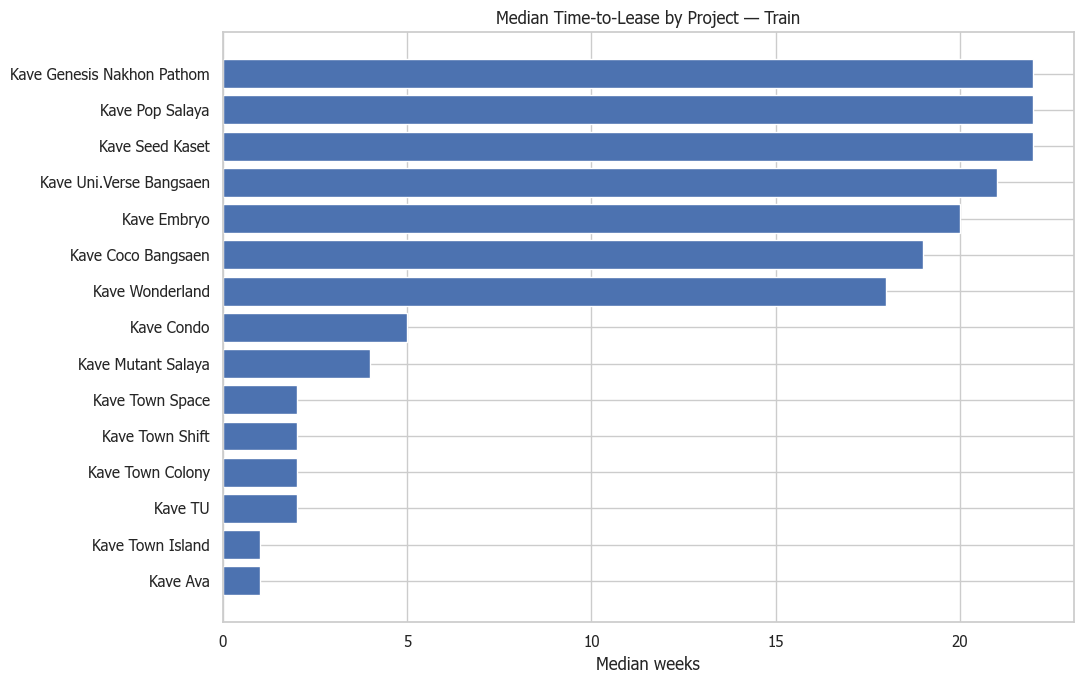

In [12]:
project_summary = (
    eda_data.groupby("project_name")[TARGET].agg(["count", "median", "mean"])
    .sort_values("median")
)
display(project_summary.round(2))
plt.figure(figsize=(11, 7))
plt.barh(project_summary.index, project_summary["median"])
plt.xlabel("Median weeks")
plt.title("Median Time-to-Lease by Project — Train")
plt.tight_layout()
plt.show()

## 10. ตลาดย้อนหลังและความสัมพันธ์ของตัวแปรตัวเลข

ใช้ Spearman Correlation เพื่อสำรวจความสัมพันธ์ตามลำดับของค่า เหมาะสำหรับดูแนวโน้มเมื่อข้อมูลเบ้ ค่าใกล้ 0 ไม่ได้ยืนยันว่าไม่มีความสัมพันธ์แบบซับซ้อน และค่า Correlation ไม่พิสูจน์เหตุและผล

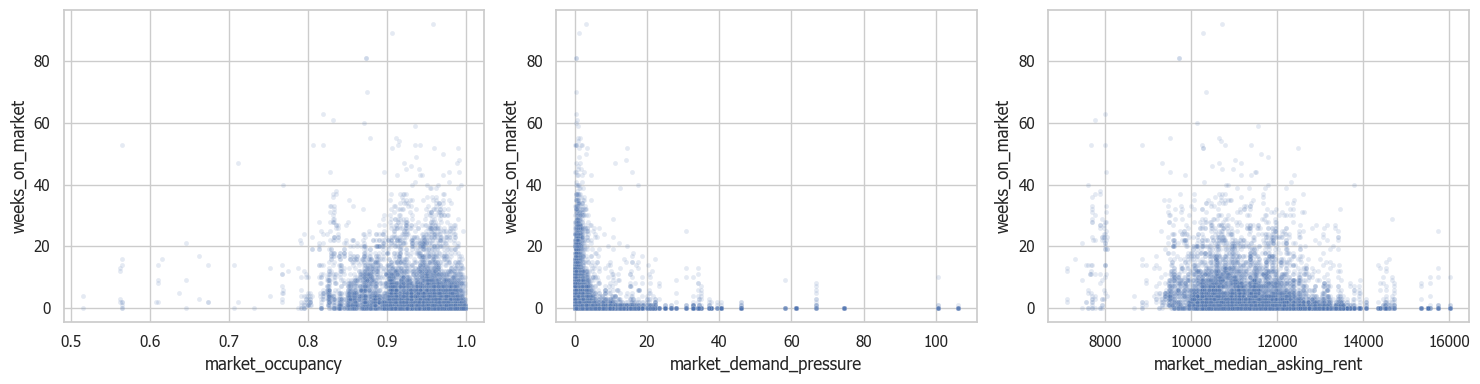

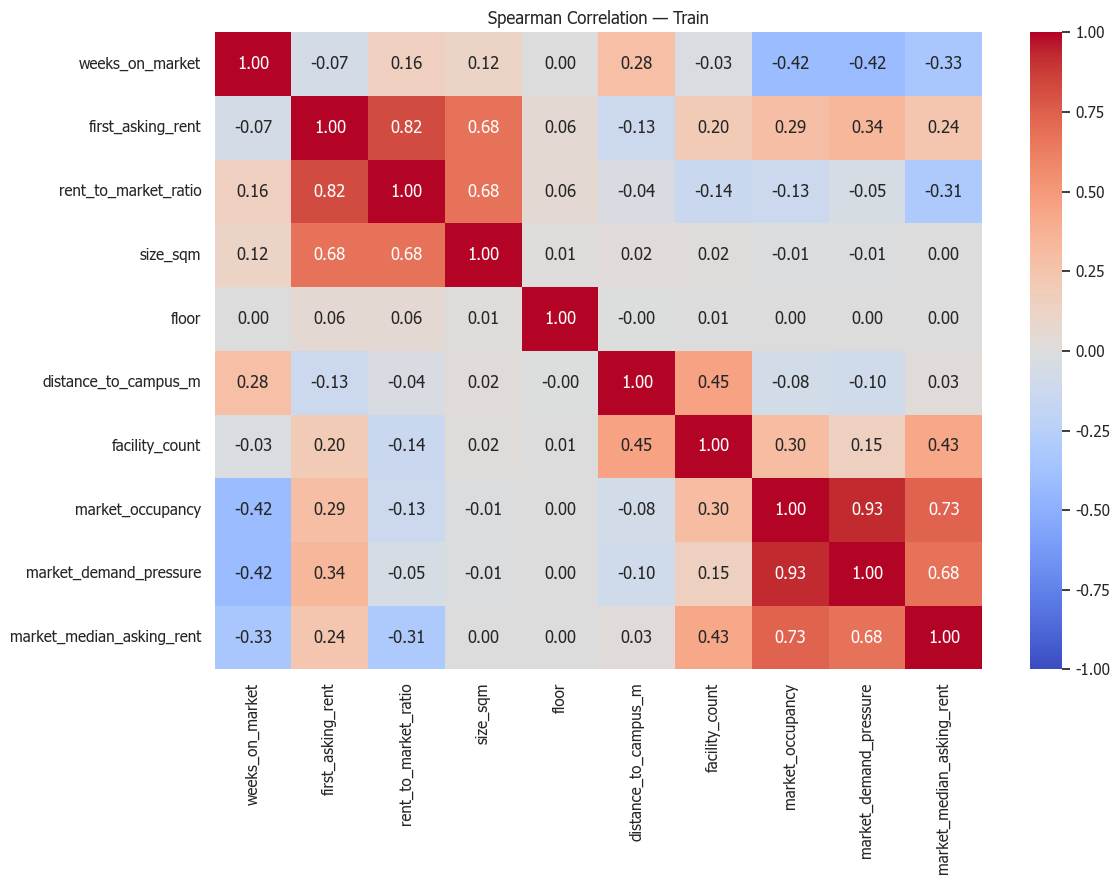

In [13]:
market_columns = ["market_occupancy", "market_demand_pressure", "market_median_asking_rent"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, market_columns):
    sns.scatterplot(data=eda_data, x=col, y=TARGET, alpha=0.15, s=12, ax=ax)
plt.tight_layout()
plt.show()

correlation_columns = [TARGET, *numeric_plot_columns, *market_columns]
correlation = eda_data[correlation_columns].corr(method="spearman")
plt.figure(figsize=(12, 9))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Spearman Correlation — Train")
plt.tight_layout()
plt.show()

## 11. แนวโน้มตามเดือนที่เริ่มลงประกาศ

ดูทั้งค่ามัธยฐานและจำนวนรายการที่ทราบผลสำเร็จแล้ว เดือนใกล้จุดตัด Train อาจเหลือเฉพาะรายการที่สำเร็จเร็ว จึงไม่ควรตีความการลดลงช่วงท้ายว่าเป็นผลของตลาดทันที

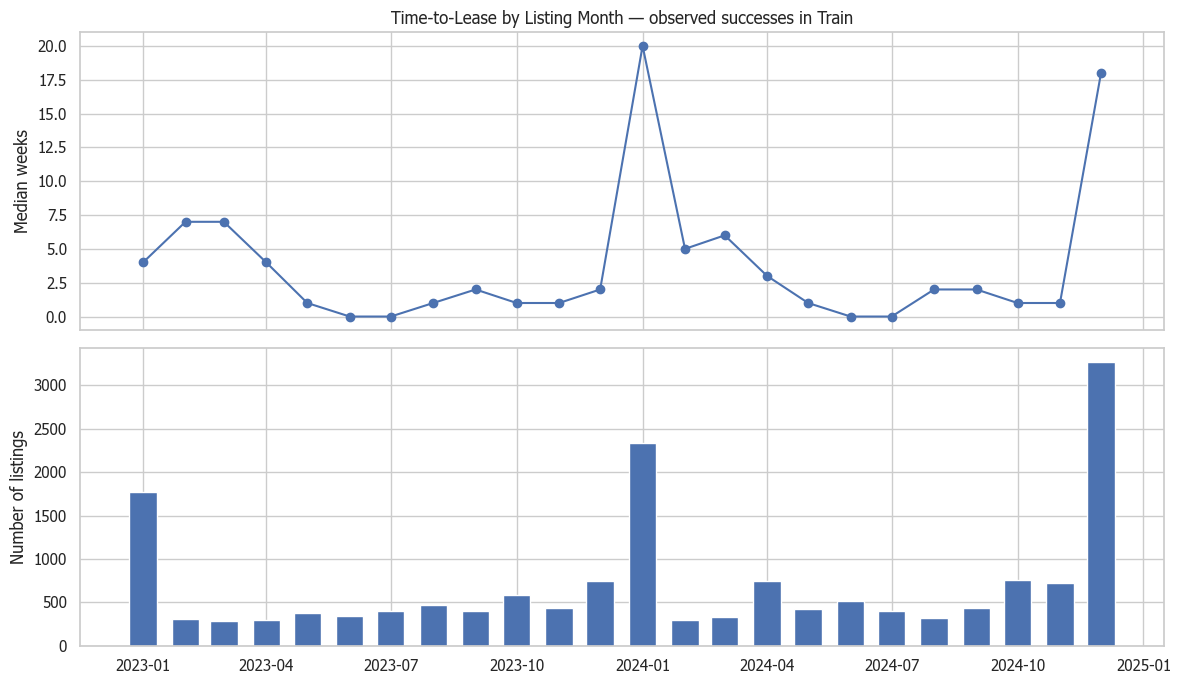

,count,median
date_listed,,
2024-07-01,400,0.0
2024-08-01,326,2.0
2024-09-01,433,2.0
2024-10-01,763,1.0
2024-11-01,722,1.0
2024-12-01,3267,18.0


In [14]:
monthly = eda_data.groupby(eda_data["date_listed"].dt.to_period("M"))[TARGET].agg(["count", "median"])
monthly.index = monthly.index.to_timestamp()
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(monthly.index, monthly["median"], marker="o")
axes[0].set_ylabel("Median weeks")
axes[0].set_title("Time-to-Lease by Listing Month — observed successes in Train")
axes[1].bar(monthly.index, monthly["count"], width=20)
axes[1].set_ylabel("Number of listings")
plt.tight_layout()
plt.show()
display(monthly.tail(6))

## 12. สรุป Feature ที่จะนำไปทดลอง

ใช้ข้อมูลที่ทราบเมื่อเริ่มลงประกาศเท่านั้น ขั้นเตรียม Pipeline ต้องเรียนรู้ค่าทดแทน Missing และการแปลงตัวแปรจาก Train

| กลุ่ม | ตัวแปร | แนวทาง |
|---|---|---|
| ห้อง | floor, size_sqm, room_type, view, furnished | ใช้คุณลักษณะ ณ วันประกาศ |
| ราคา | first_asking_rent, rent_to_market_ratio | ใช้ราคาตั้งต้นและตลาดย้อนหลัง |
| ทำเลและโครงการ | project_id, distance_to_campus_m, facility_count | project_id ต้องเป็นหมวดหมู่ |
| เวลา | listing_month, listing_year, season_listed | ตรวจนิยามฤดูกาลว่าเป็นปฏิทินที่รู้ล่วงหน้า |
| ตลาด | market_occupancy, market_demand_pressure, market_median_asking_rent | ข้อมูลสัปดาห์ก่อน |
| Missing | missing_market_history | แจ้งว่าไม่มีข้อมูลตลาดย้อนหลัง |

**ไม่ใช้เป็น Feature:** weeks_on_market (Target), leased, week_leased, outcome_available_at, n_viewings, tenant_segment, lease_months และ asking_rent ล่าสุด เพราะเป็นผลลัพธ์หรืออาจเกิดหลังลงประกาศ

listing_id และ unit_id เก็บไว้ตรวจสอบข้อมูล ไม่ใช้เป็นตัวทำนายรุ่นแรก ห้องเดิมอาจอยู่หลายช่วงเวลา จึงควรรายงานภายหลังว่าเป็นการทำนายห้องที่เคยเห็นหรือห้องใหม่

In [15]:
candidate_features = [
    "floor", "size_sqm", "room_type", "view", "furnished",
    "first_asking_rent", "rent_to_market_ratio",
    "project_id", "distance_to_campus_m", "facility_count",
    "listing_month", "listing_year", "season_listed",
    "market_occupancy", "market_demand_pressure", "market_median_asking_rent",
    "missing_market_history"
]
forbidden_features = {
    TARGET, "leased", "week_leased", "outcome_available_at",
    "n_viewings", "tenant_segment", "lease_months", "asking_rent"
}
assert not set(candidate_features) & forbidden_features
assert set(candidate_features).issubset(eda_data.columns)
display(eda_data[candidate_features].isna().sum().to_frame("Missing ใน Train"))
print("จำนวน Feature ที่เสนอ:", len(candidate_features))

จำนวน Feature ที่เสนอ: 17


,Missing ใน Train
floor,0
size_sqm,0
room_type,0
view,0
furnished,0
first_asking_rent,0
rent_to_market_ratio,6067
project_id,0
distance_to_campus_m,0
facility_count,0


## 13. สรุปผลจากข้อมูลที่รันจริง

ตัวเลขด้านล่างคำนวณใหม่เมื่อ Run All เพื่อให้รายงานสอดคล้องกับข้อมูล กราฟแสดงความสัมพันธ์จากชุด Train และยังไม่มีผลการฝึกโมเดล

In [16]:
print(f"ประกาศหลังตรวจรายการทางเลือก: {len(clean_listings):,} แถว")
print(f"Matured Train ที่ปล่อยเช่าสำเร็จ: {len(eda_data):,} แถว")
print(f"Target มัธยฐาน: {eda_data[TARGET].median():.2f} สัปดาห์")
print(f"Target ค่าเฉลี่ย: {eda_data[TARGET].mean():.2f} สัปดาห์")
print(f"Target สูงสุด: {eda_data[TARGET].max():.0f} สัปดาห์")
print(f"สำเร็จในสัปดาห์เดียวกัน: {eda_data[TARGET].eq(0).sum():,} แถว")
print(f"ไม่มีตลาดย้อนหลังใน Train: {eda_data['missing_market_history'].sum():,} แถว")
top_relationships = correlation[TARGET].drop(TARGET).dropna()
display(top_relationships.reindex(top_relationships.abs().sort_values(ascending=False).index)
        .head(5).to_frame("Spearman กับ Target").round(3))

ประกาศหลังตรวจรายการทางเลือก: 30,478 แถว
Matured Train ที่ปล่อยเช่าสำเร็จ: 16,993 แถว
Target มัธยฐาน: 3.00 สัปดาห์
Target ค่าเฉลี่ย: 8.44 สัปดาห์
Target สูงสุด: 129 สัปดาห์
สำเร็จในสัปดาห์เดียวกัน: 3,896 แถว
ไม่มีตลาดย้อนหลังใน Train: 6,067 แถว


,Spearman กับ Target
market_demand_pressure,-0.425
market_occupancy,-0.419
market_median_asking_rent,-0.329
distance_to_campus_m,0.281
rent_to_market_ratio,0.161


### ข้อสรุปสำหรับการทำงานต่อ

ผลรันข้อมูลปัจจุบันใช้ Matured Train ถึงสิ้นปี 2024 และกันข้อมูลหลังมิถุนายน 2025 เป็น `post_test` เพื่อไม่ให้ right-censoring ทำให้ Test เหลือเฉพาะห้องที่ปล่อยเร็ว ตัวเลขสรุปทั้งหมดสร้างจากโค้ดด้านบนและควรรันใหม่เมื่อเปลี่ยนชุดข้อมูล

1. เก็บค่า 0 ที่ตรวจสอบแล้วว่าเป็นการสำเร็จในสัปดาห์เดียวกัน
2. ยังไม่ลบระยะเวลานานตามเกณฑ์ Outlier อัตโนมัติ เพราะอาจเป็นเหตุการณ์จริง
3. เปรียบเทียบ Target เดิมกับ log1p ได้ในขั้นพัฒนาโมเดล โดยวัด MAE/RMSE กลับเป็นสัปดาห์
4. กรณีตลาดย้อนหลังหายไป ให้ทดลอง imputation ที่เรียนจาก Train พร้อม Missing indicator
5. สร้าง `time_to_lease_features.py` จากกติกาที่ตรวจใน Notebook นี้ แล้วเปรียบเทียบ Multiple Linear Regression กับ Random Forest Regressor โดยเลือกจาก Validation MAE
6. เลือกโมเดลจาก Validation เท่านั้น เปิด Matured Test เพื่อประเมินเมื่อเลือกโมเดลแล้ว และไม่ใช้ `post_test` วัดผล
7. รายงานข้อจำกัดจากข้อมูลจำลอง การเลือกเฉพาะประกาศสำเร็จ ความละเอียดระดับสัปดาห์ และ Censoring ที่อาจยังเหลือเล็กน้อย ผล What-if เป็นการประมาณจากความสัมพันธ์ ไม่ใช่หลักฐานเชิงเหตุและผล

Notebook นี้เป็นงาน EDA จึงยังไม่บันทึก Modeling CSV หรือฝึกโมเดล

## 14. งานอ้างอิงที่ใช้ประกอบแนวทาง

- Castelli, M., Dobreva, M., Henriques, R., & Vanneschi, L. (2020). [Predicting Days on Market to Optimize Real Estate Sales Strategy](https://onlinelibrary.wiley.com/doi/10.1155/2020/4603190). ใช้อ้างอิงแนวทาง Regression และการเปรียบเทียบ Random Forest สำหรับระยะเวลาประกาศ ไม่ได้ยืนยันวันทำสัญญาเช่าทุกรายการ
- Ermolin, S. V. (2016). [Predicting Days-on-Market for Residential Real Estate Sales](https://cs229.stanford.edu/proj2016/report/ermolin_predicting_Days_on_Market_for_Residential_Real_Estate_Sales_report.pdf). รายงานโครงงาน CS229 ใช้ Linear Regression, Decision Tree และ Random Forest ในตลาดขาย ใช้เป็นแนวทางประกอบ ไม่ใช่งานวารสารหรือหลักฐานตรงของตลาดเช่า
- Allen, M. T., Rutherford, R. C., & Thomson, T. A. (2009). [Residential Asking Rents and Time on the Market](https://faculty.business.utsa.edu/tthomson/papers/AllenRutherfordThomsonAskingRentsJRFE2009.pdf). รองรับความเกี่ยวข้องของราคาตั้งต้นกับเวลาปล่อยเช่า งานนี้ใช้ duration model
- Yilmaz, O., Talavera, O., & Jia, Y. J. (2022). [Rental Market Liquidity, Seasonality, and Distance to Universities](https://cronfa.swansea.ac.uk/Record/cronfa59211). รองรับการศึกษาฤดูกาลและระยะทางจากมหาวิทยาลัย งานนี้ใช้ survival analysis

อ้างอิงเหล่านี้ใช้ประกอบเหตุผลในการทดลอง ไม่ได้ยืนยันว่า Random Forest จะดีที่สุดกับข้อมูลของเรา